In [1]:
import pandas as pd
import numpy as np 

ser = pd.Series(np.linspace(3,33,5))
print(ser)

0     3.0
1    10.5
2    18.0
3    25.5
4    33.0
dtype: float64


In [17]:
data = pd.read_csv("50_Startups (1).csv")
print(data.info())
print(data.columns)
print(data.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   R&D Spend        52 non-null     float64
 1   Administration   52 non-null     float64
 2   Marketing Spend  52 non-null     float64
 3   State            51 non-null     object 
 4   Profit           49 non-null     float64
dtypes: float64(4), object(1)
memory usage: 2.2+ KB
None
Index(['R&D Spend', 'Administration', 'Marketing Spend', 'State', 'Profit'], dtype='object')
(52, 5)


In [18]:
print(data.describe())
print(data.isnull().sum())
print(data.head())

           R&D Spend  Administration  Marketing Spend         Profit
count      52.000000       52.000000        52.000000      49.000000
mean    91309.139423   138132.177885    223892.040769  128902.600204
std    136143.544578   124921.771947    163361.620695  133085.166699
min         0.000000    51283.140000         0.000000   14681.400000
25%     42692.090000   105077.645000    125324.665000   90708.190000
50%     73051.080000   122699.795000    212716.240000  107404.340000
75%    105065.712500   145190.700000    300632.782500  134307.350000
max    999999.990000   999999.990000    999999.990000  999999.990000
R&D Spend          0
Administration     0
Marketing Spend    0
State              1
Profit             3
dtype: int64
   R&D Spend  Administration  Marketing Spend       State     Profit
0  165349.20       136897.80        471784.10    New York  192261.83
1  162597.70       151377.59        443898.53  California  191792.06
2  153441.51       101145.55        407934.54     Flor

In [20]:
missing_rows = data[data.isnull().any(axis=1)]
print(missing_rows)

    R&D Spend  Administration  Marketing Spend     State    Profit
5   131876.90        99814.71        362861.36  New York       NaN
10  101913.08       110594.11        229160.95   Florida       NaN
32   61136.38       152701.92         88218.23       NaN  97483.56
39   20229.59        65947.93        185265.10  New York       NaN


In [5]:
data_fill = data.fillna({
    'Profit' : data['Profit'].mean(),
    'State' : data['State'].ffill()
})
data = data_fill
print(data.isnull().sum())
print(data[data.isnull().any(axis=1)])

R&D Spend          0
Administration     0
Marketing Spend    0
State              0
Profit             0
dtype: int64
Empty DataFrame
Columns: [R&D Spend, Administration, Marketing Spend, State, Profit]
Index: []


In [6]:
print(data.duplicated().sum())
print(data[data.duplicated()])
data = data.drop_duplicates()
print(data.duplicated().sum())

1
    R&D Spend  Administration  Marketing Spend    State    Profit
31   61994.48       115641.28         91131.24  Florida  99937.59
0


## Correlation

Correlation is a statistical method used to measure the relationship between two variables.

- A value close to `+1` means a strong positive relationship.
- A value close to `-1` means a strong negative relationship.
- A value near `0` means no strong relationship.

In [ ]:
print("Correlation of Marketing Spend with Profit:")
print(data["Marketing Spend"].corr(data["Profit"]))


print("Correlation of R&D with Profit:")
print(data["R&D Spend"].corr(data["Profit"]))

Correlation of Marketing Spend with Profit:
0.8067466925485668
Correlation of R&D with Profit:
0.9936212614685173


- A Box Plot (or Box-and-Whisker Plot) is used to show the distribution of data

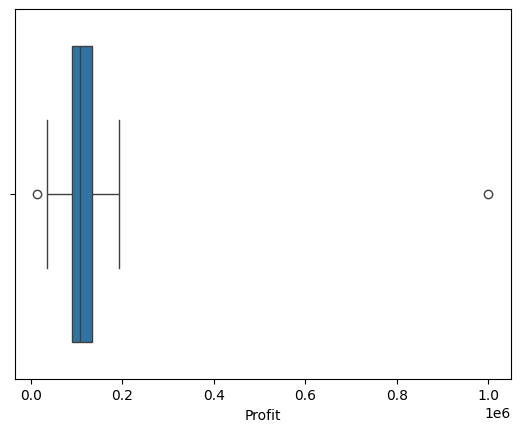

14681.4
999999.99
128902.6
107404.34


<Axes: xlabel='R&D Spend'>

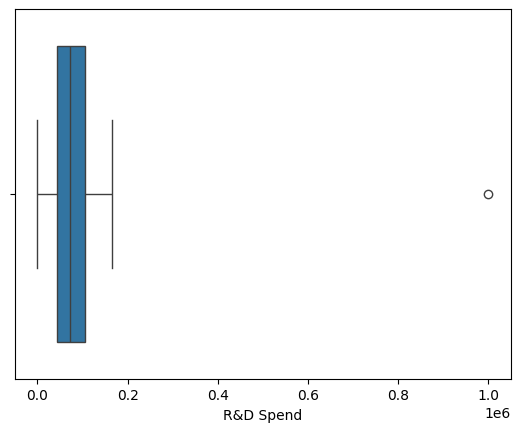

In [24]:
import seaborn as sns 
import matplotlib.pyplot as plt

sns.boxplot(x=data["Profit"])
plt.show()
print(data["Profit"].min().round(2))
print(data["Profit"].max().round(2))
print(data["Profit"].mean().round(2))
print(data["Profit"].median().round(2))
sns.boxplot(x=data['R&D Spend'])

0.25 and 0.75 are used to calculate the first quartile (Q1) and third quartile (Q3). These help identify the middle 50% of the data. 

IQR = Q3 - Q1 measures data spread. 

1.5 * IQR is a standard rule used to detect outliers. Any value outside the lower and upper limits is considered an outlier.

In [9]:
Q1 = data["Profit"].quantile(0.25)
Q2 = data["Profit"].quantile(0.75)

IQR = Q2 - Q1
lower = Q1 - 1.5*IQR
Upper = Q2 + 1.5*IQR

outliers = data[(data["Profit"] < lower) | (data["Profit"] > Upper)]

print(outliers)

    R&D Spend  Administration  Marketing Spend       State     Profit
49  999999.99       999999.99        999999.99       Texas  999999.99
51       0.00       116983.80         45173.06  California   14681.40


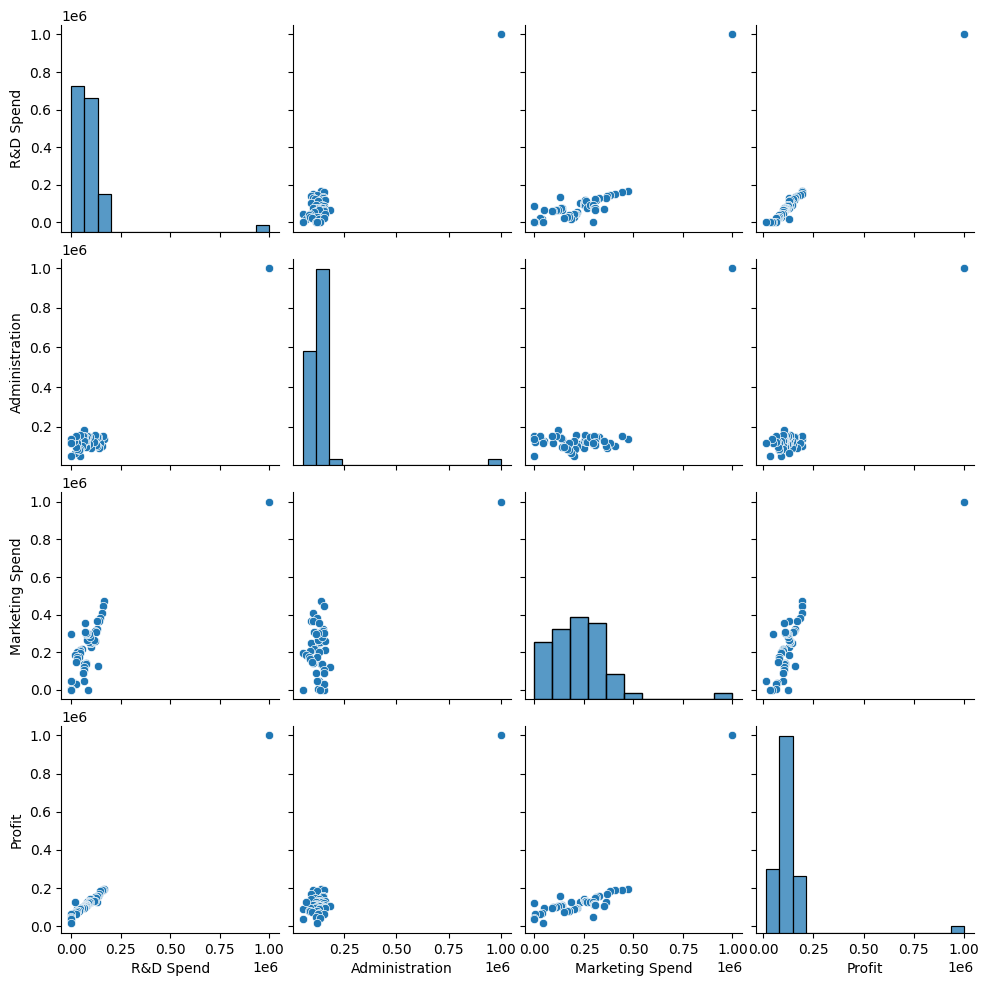

In [10]:
sns.pairplot(data)

array([[<Axes: title={'center': 'R&D Spend'}>,
        <Axes: title={'center': 'Administration'}>],
       [<Axes: title={'center': 'Marketing Spend'}>,
        <Axes: title={'center': 'Profit'}>]], dtype=object)

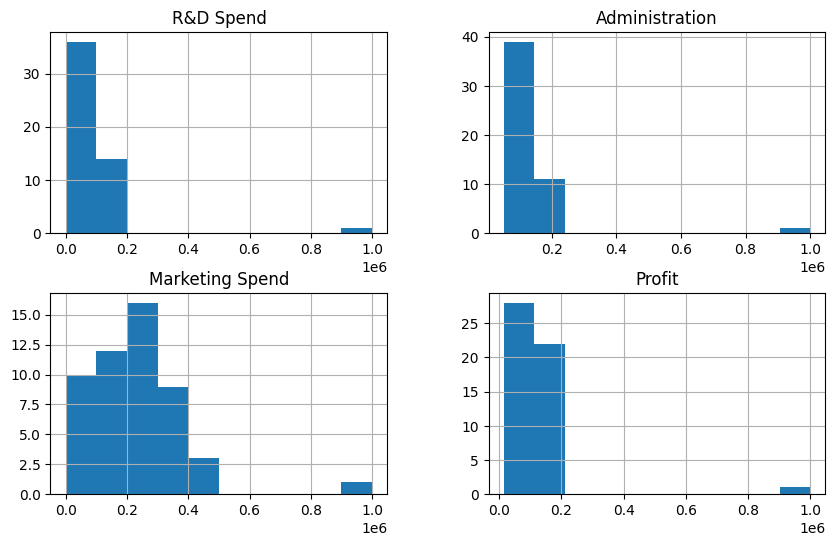

In [11]:
data.hist(figsize=(10,6))

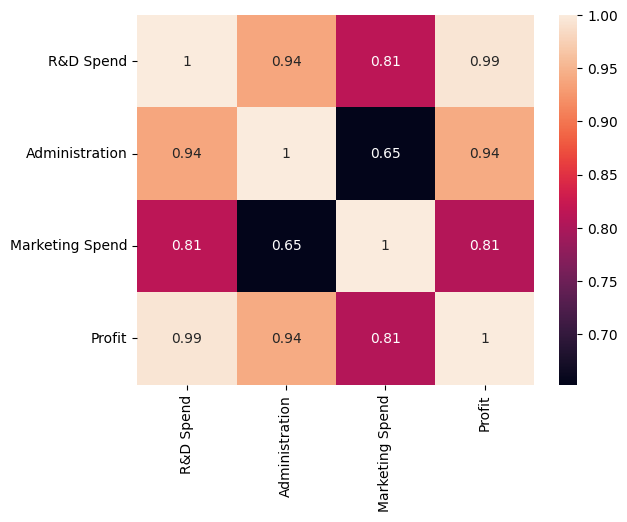

In [12]:
corr = data.corr(numeric_only=True)
sns.heatmap(corr , annot=True)
plt.show()

In [13]:
print(data.skew(numeric_only=True))

R&D Spend          5.963856
Administration     6.603812
Marketing Spend    2.007687
Profit             6.162968
dtype: float64
